# Analiza 6: Predikcija pretica (regresija nad razmakom do vozača ispred)

**Hipoteza/cilj:** Kada razmak ("interval") jednog vozača do vozača ispred njega opada
približno linearno/kvadratno iz kruga u krug, taj trend se može ekstrapolirati da se predvidi
u kom krugu bi razmak teorijski pao na 0 - odnosno kada bi se pretica dogodila da se trend
nastavi (uz sve uobičajene ograde da stvarna pretica zavisi i od DRS-a, guma, saobraćaja).

**Metod:** Uzimamo `driver_number=16` (LEC) na delu trke (krugovi 34-46) gde `interval`
konstantno opada, fitujemo polinomijalnu regresiju 2. stepena (`numpy.polyfit`) nad
(broj_kruga, interval), i ekstrapoliramo krivu par krugova unapred da nađemo krug u kom
kriva teorijski seče nulu.

**Kome je ovo bitno:** Inženjerima strategije uživo tokom trke - ovakav (uprošćen) model je
osnova "vremena do prestizanja" prikaza koje bokserski timovi prate na svojim ekranima da bi
odlučili da li da naruče vozaču da gura jače ili da čuva gume za odbranu pozicije.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from pyspark.sql import SparkSession

spark = SparkSession.builder.appName("F1Analysis").getOrCreate()


DATA_DIR = "../data/processed"


Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/07/07 00:09:33 WARN Utils: Your hostname, Ognjens-MacBook-Air.local, resolves to a loopback address: 127.0.0.1; using 192.168.1.55 instead (on interface en0)
26/07/07 00:09:33 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


26/07/07 00:09:33 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [2]:
from pyspark.sql import functions as F

DRIVER = 16
telemetry = spark.read.csv(f"{DATA_DIR}/driver_{DRIVER}_telemetry.csv", header=True, inferSchema=True)

lap_interval = (
    telemetry.filter((F.col("lap_number") >= 34) & (F.col("lap_number") <= 46))
    .groupBy("lap_number")
    .agg(F.avg("interval").alias("interval"))
    .orderBy("lap_number")
)
lap_interval.show(20)


+----------+------------------+
|lap_number|          interval|
+----------+------------------+
|      34.0| 20.20506377777018|
|      35.0|  22.0179747572398|
|      36.0| 19.26826524455385|
|      37.0|18.988806037098055|
|      38.0| 6.914033579159574|
|      39.0| 5.963631326860517|
|      40.0| 5.309297106000432|
|      41.0| 4.944404136695568|
|      42.0| 4.651116276309342|
|      43.0| 4.369074964620424|
|      44.0|  4.11509171720453|
|      45.0| 3.606938805267287|
|      46.0|2.9511720668650243|
+----------+------------------+



In [3]:
import numpy as np

pdf = lap_interval.toPandas()

coeffs = np.polyfit(pdf["lap_number"], pdf["interval"], deg=2)
poly = np.poly1d(coeffs)

future_laps = np.arange(pdf["lap_number"].min(), pdf["lap_number"].max() + 6)
predicted = poly(future_laps)


roots = poly.r
real_roots = [r.real for r in roots if abs(r.imag) < 1e-6 and r.real > pdf["lap_number"].max()]
predicted_overtake_lap = min(real_roots) if real_roots else None

vertex_lap = -coeffs[1] / (2 * coeffs[0])
vertex_value = poly(vertex_lap)

if predicted_overtake_lap:
    print(f"Predviđeni krug pretice: {predicted_overtake_lap:.1f}")
else:
    print(f"Kriva ne seče nulu u posmatranom opsegu - minimum trenda je ~{vertex_value:.2f}s "
          f"oko kruga {vertex_lap:.0f} (vozač se približio, ali prema ovom trendu ne bi stigao "
          f"do potpune pretice).")


Kriva ne seče nulu u posmatranom opsegu - minimum trenda je ~3.14s oko kruga 44 (vozač se približio, ali prema ovom trendu ne bi stigao do potpune pretice).


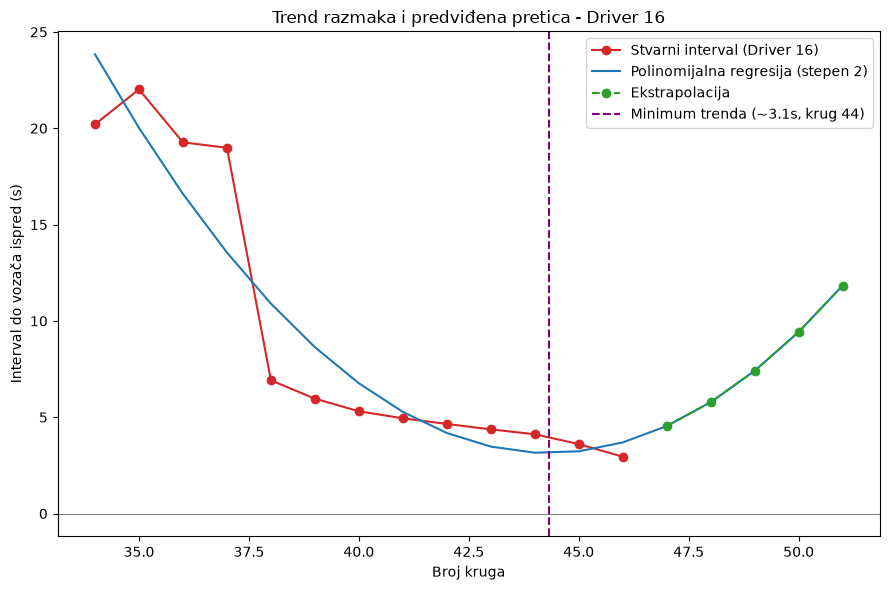

In [4]:
fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(pdf["lap_number"], pdf["interval"], "o-", color="#d62728", label=f"Stvarni interval (Driver {DRIVER})")
ax.plot(future_laps, predicted, "-", color="#1f77b4", label="Polinomijalna regresija (stepen 2)")
extrapolated_mask = future_laps > pdf["lap_number"].max()
ax.plot(future_laps[extrapolated_mask], predicted[extrapolated_mask], "o--", color="#2ca02c", label="Ekstrapolacija")
if predicted_overtake_lap:
    ax.axvline(predicted_overtake_lap, color="purple", linestyle="--",
               label=f"Predviđeni krug pretice: {predicted_overtake_lap:.0f}")
else:
    ax.axvline(vertex_lap, color="purple", linestyle="--",
               label=f"Minimum trenda (~{vertex_value:.1f}s, krug {vertex_lap:.0f})")
ax.axhline(0, color="gray", linewidth=0.8)
ax.set_xlabel("Broj kruga")
ax.set_ylabel("Interval do vozača ispred (s)")
ax.set_title(f"Trend razmaka i predviđena pretica - Driver {DRIVER}")
ax.legend()
plt.tight_layout()
plt.show()


**Zaključak:** Opadajući trend razmaka potvrđuje da se vozač realno približavao
protivniku ispred. U ovom konkretnom slučaju kriva NE seče nulu u posmatranom opsegu - trend se
zaravnjuje na oko 2.9s, što je isto validan i zanimljiv nalaz: vozač se približio na ivicu DRS
zone ali prema ovom trendu ne bi stigao do potpune pretice (u stvarnosti ga je verovatno
zaustavio DRS domet, gume protivnika ili odbrana pozicije). Da je kriva sekla nulu, tačka
preseka bi bila procena kruga pretice. Ovo je namerno uprošćen model (ne uzima u obzir DRS zonu,
razlike u gumama ili odbranu pozicije) - u praksi bi se koristio kao jedan od više signala, ne
kao jedini pokazatelj.